# Breast Cancer Prediction Analysis

In this notebook, I analyze a breast cancer dataset from Kaggle.
The goal is to understand which cell measurements are most connected to diagnosis.

## What does one row represent?

One row represents one patient.
For each patient, we have measurements from a tissue sample (cell nuclei seen in a microscope image), plus a diagnosis label:
- `0` = benign (not cancer)
- `1` = malignant (cancer)

So when I say "a patient has a low radius," I mean the value in that patient's row.

## What population does this dataset describe?

The population in this dataset is patients from the University of Wisconsin Hospitals (Madison), where the samples were collected.
That matters because this dataset does not automatically represent all patients everywhere.
The patterns I find should be interpreted as patterns in this specific group.

## Columns in the dataset

| Column | What it means |
|---|---|
| mean_radius | Average size (radius) of the cell nucleus |
| mean_texture | How rough or smooth the cell surface looks |
| mean_perimeter | The boundary length around the cell nucleus |
| mean_area | The total area of the cell nucleus |
| mean_smoothness | How smooth the edges of the nucleus are |
| diagnosis | 0 = Benign (not cancer), 1 = Malignant (cancer) |

## Analytical Questions

I will try to answer these three questions through my analysis:

1. **Do cell measurements differ between benign and malignant tumors?**
2. **Which measurement is most strongly connected to a malignant diagnosis?**
3. **Is there a combination of measurements that clearly separates benign from malignant cases?**

Dataset source: https://www.kaggle.com/datasets/merishnasuwal/breast-cancer-prediction-dataset

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# raw copy as the starting point of the pipeline
df_raw = pd.read_csv("data/Breast_cancer_data.csv")

df_raw.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


## Data Cleaning Pipeline

Before doing any analysis, I clean the data in a structured way so the later results are easier to trust and explain.

I use this pipeline on purpose:
1. **Inspect quality first** to see what is actually wrong (missing values, duplicates, invalid diagnosis values, negative measurements).
2. **Convert data types** so numeric operations are consistent and do not fail silently.
3. **Fix issues with clear rules** instead of random edits:
   - remove duplicate rows
   - keep only valid diagnosis values (0 and 1)
   - fill missing numeric values with median (robust against outliers)
   - clip negative measurements to 0 because these physical measurements should not be negative

Even when the dataset is mostly clean, this step is still important: it makes the workflow reproducible and shows exactly how I protect the analysis from data quality problems.

In [64]:
def inspect_data_quality(df):
    """Return simple quality metrics before cleaning."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    quality = {
        "rows": len(df),
        "columns": df.shape[1],
        "missing_values_total": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "diagnosis_unique_values": sorted(df["diagnosis"].dropna().unique().tolist()),
        "negative_values_in_numeric": int((df[numeric_cols] < 0).sum().sum()),
    }
    return quality


def convert_data_types(df):
    """Convert columns to expected data types."""
    df_out = df.copy()

    feature_cols = [col for col in df_out.columns if col != "diagnosis"]
    for col in feature_cols:
        df_out[col] = pd.to_numeric(df_out[col], errors="coerce")

    df_out["diagnosis"] = pd.to_numeric(df_out["diagnosis"], errors="coerce").astype("Int64")
    return df_out


def fix_data_issues(df):
    """Fix common issues in a simple and transparent way."""
    df_out = df.copy()

    # Drop duplicate rows.
    df_out = df_out.drop_duplicates()

    # Keep only valid diagnosis values (0 and 1).
    df_out = df_out[df_out["diagnosis"].isin([0, 1])]

    # Fill missing numeric values with median.
    numeric_cols = df_out.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df_out[col] = df_out[col].fillna(df_out[col].median())

    # Numeric measurements should not be negative in this dataset.
    feature_cols = [col for col in numeric_cols if col != "diagnosis"]
    for col in feature_cols:
        df_out[col] = df_out[col].clip(lower=0)

    return df_out


# Pipeline execution
quality_before = inspect_data_quality(df_raw)
df_typed = convert_data_types(df_raw)
df = fix_data_issues(df_typed)  # from now on, use df as cleaned data
quality_after = inspect_data_quality(df)

print("Quality before cleaning:")
print(quality_before)
print("\nQuality after cleaning:")
print(quality_after)
print("\nCleaned shape:", df.shape)

Quality before cleaning:
{'rows': 569, 'columns': 6, 'missing_values_total': 0, 'duplicate_rows': 0, 'diagnosis_unique_values': [0, 1], 'negative_values_in_numeric': 0}

Quality after cleaning:
{'rows': 569, 'columns': 6, 'missing_values_total': 0, 'duplicate_rows': 0, 'diagnosis_unique_values': [0, 1], 'negative_values_in_numeric': 0}

Cleaned shape: (569, 6)


### Why this cleaning result still matters

After running the pipeline, I can see there are no duplicates or missing values, and the cleaned shape matches the raw shape. That tells me this specific dataset was already in good condition.

But keeping the pipeline still matters for two reasons:
- It documents the exact quality checks I rely on before analysis.
- It makes the workflow reusable if I run the same analysis on messier data later.

Before visualizations, I still run a quick structure check of the cleaned data:

* number of rows and columns
* column names
* data types
* missing values
* summary statistics

In [65]:
df.shape

(569, 6)

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    Int64  
dtypes: Int64(1), float64(5)
memory usage: 27.4 KB


In [67]:
df.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.0
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.0
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.0
50%,13.370000,18.840000,86.240000,551.100000,0.095870,1.0
75%,15.780000,21.800000,104.100000,782.700000,0.105300,1.0
max,28.110000,39.280000,188.500000,2501.000000,0.163400,1.0


In [68]:
df.isnull().sum()

mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

In [69]:
print(df['diagnosis'].value_counts())

diagnosis
1    357
0    212
Name: count, dtype: Int64


In [70]:
df.groupby('diagnosis')[['mean_radius', 'mean_area']].mean()

,mean_radius,mean_area
diagnosis,,
0,17.462830,978.376415
1,12.146524,462.790196


## A practical way to approach this analysis

One way to approach this analysis is to do a quick numeric checkpoint before plotting.

I first split the dataset into benign and malignant groups using boolean masking, so I can verify whether the group differences are already visible in simple averages.

Then I use explicit NumPy to calculate feature-to-diagnosis correlations in a transparent way. This gives a clear ranking of which variables seem most informative before moving on to visual interpretation.

So this step works as a bridge: first a compact numeric check, then visual exploration of the same patterns.

In [71]:
# One practical checkpoint before plotting: compare groups numerically
benign = df[df["diagnosis"] == 0]
malignant = df[df["diagnosis"] == 1]

group_compare = pd.DataFrame({
    "benign_mean": benign[["mean_radius", "mean_perimeter", "mean_area"]].mean(),
    "malignant_mean": malignant[["mean_radius", "mean_perimeter", "mean_area"]].mean(),
})
print("Quick group comparison using boolean masking:")
print(group_compare.round(2))

# Explicit NumPy: rank how strongly each feature relates to diagnosis
features = ["mean_radius", "mean_texture", "mean_perimeter", "mean_area", "mean_smoothness"]
y = df["diagnosis"].to_numpy()

np_corr = {
    col: np.corrcoef(df[col].to_numpy(), y)[0, 1]
    for col in features
}
np_corr = pd.Series(np_corr).sort_values()

print("\nFeature-to-diagnosis correlations (NumPy):")
print(np_corr.round(2))

strongest = np_corr.abs().idxmax()
print(f"\nStrongest feature by absolute correlation: {strongest}")

Quick group comparison using boolean masking:
                benign_mean  malignant_mean
mean_radius           17.46           12.15
mean_perimeter       115.37           78.08
mean_area            978.38          462.79

Feature-to-diagnosis correlations (NumPy):
mean_perimeter    -0.74
mean_radius       -0.73
mean_area         -0.71
mean_texture      -0.42
mean_smoothness   -0.36
dtype: float64

Strongest feature by absolute correlation: mean_perimeter


## Visualisation: Boxplots

Starting with the first question for this analysis: do cell measurements differ between benign and malignant tumors?

A boxplot is a good starting point because it shows me the median, the spread, and any outliers for each group side by side. If the boxes are clearly separated, it means the measurement is a strong signal for diagnosis.

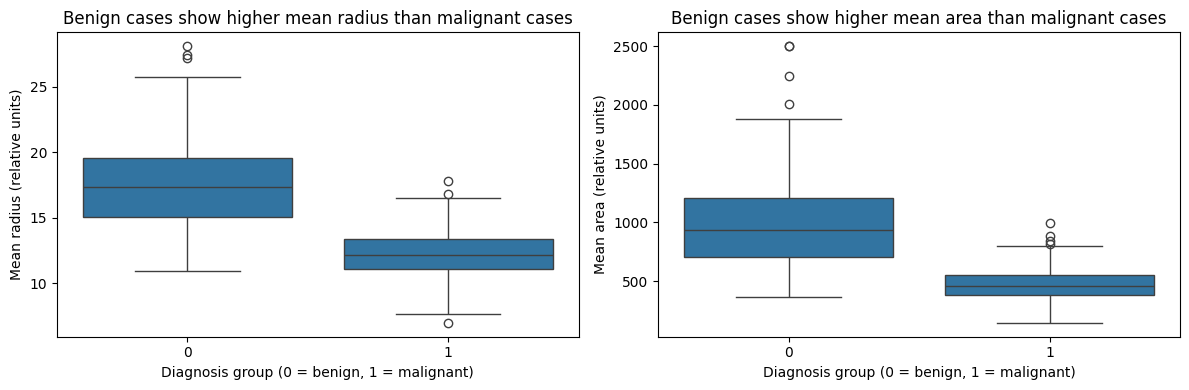

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='diagnosis', y='mean_radius', data=df, ax=axes[0])
axes[0].set_title('Benign cases show higher mean radius than malignant cases')
axes[0].set_xlabel('Diagnosis group (0 = benign, 1 = malignant)')
axes[0].set_ylabel('Mean radius (relative units)')

sns.boxplot(x='diagnosis', y='mean_area', data=df, ax=axes[1])
axes[1].set_title('Benign cases show higher mean area than malignant cases')
axes[1].set_xlabel('Diagnosis group (0 = benign, 1 = malignant)')
axes[1].set_ylabel('Mean area (relative units)')

plt.tight_layout()
plt.show()

## Visualisation: Histogram

The boxplots gave me a summary view. Now I want to see the full distribution: where values are concentrated and how much the groups overlap.

I choose a **count histogram** (not density) on purpose. Here, the number of patients in each range is part of the story, so showing raw counts is more informative for this question.

I also mark the overlap zone directly in the plot, because that zone explains why one feature alone cannot perfectly separate every case.

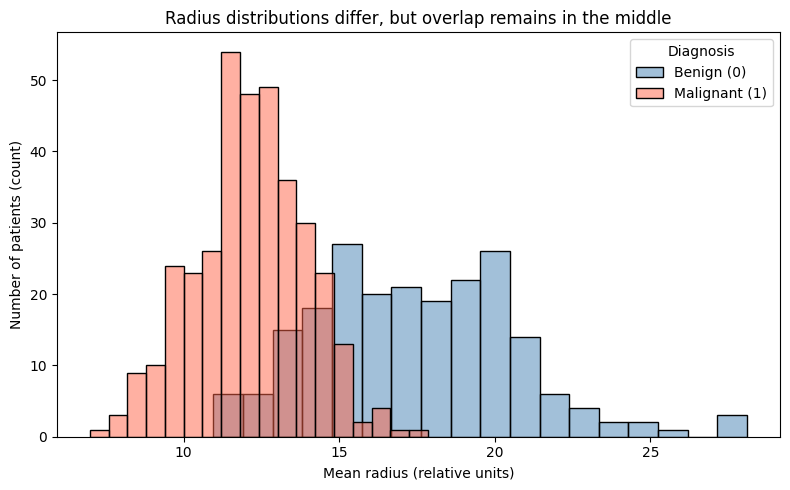

In [73]:
plot_df = df.copy()
plot_df['diagnosis_label'] = plot_df['diagnosis'].map({0: 'Benign (0)', 1: 'Malignant (1)'})

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=plot_df[plot_df['diagnosis_label'] == 'Benign (0)'],
    x='mean_radius',
    bins=18,
    alpha=0.5,
    color='steelblue',
    label='Benign (0)',
    ax=ax
)

sns.histplot(
    data=plot_df[plot_df['diagnosis_label'] == 'Malignant (1)'],
    x='mean_radius',
    bins=18,
    alpha=0.5,
    color='tomato',
    label='Malignant (1)',
    ax=ax
)

# Mark overlap in the middle using IQR overlap between the two groups.
benign_q1, benign_q3 = plot_df.loc[plot_df['diagnosis_label'] == 'Benign (0)', 'mean_radius'].quantile([0.25, 0.75])
mal_q1, mal_q3 = plot_df.loc[plot_df['diagnosis_label'] == 'Malignant (1)', 'mean_radius'].quantile([0.25, 0.75])
overlap_low = max(benign_q1, mal_q1)
overlap_high = min(benign_q3, mal_q3)

if overlap_low < overlap_high:
    ax.axvspan(overlap_low, overlap_high, color='gold', alpha=0.2, label='Overlap zone')
    ymax = ax.get_ylim()[1]
    ax.annotate(
        'Overlap zone: both groups appear here',
        xy=((overlap_low + overlap_high) / 2, ymax * 0.78),
        xytext=((overlap_low + overlap_high) / 2 + 0.6, ymax * 0.9),
        arrowprops=dict(arrowstyle='->', color='black', lw=1),
        fontsize=9
    )

ax.set_title('Radius distributions differ, but overlap remains in the middle')
ax.set_xlabel('Mean radius (relative units)')
ax.set_ylabel('Number of patients (count)')
ax.legend(title='Diagnosis')

plt.tight_layout()
plt.show()

### What this tells me (Question 1)

The first question was whether the two diagnosis groups differ in their measurements. Based on the boxplots and histogram, the answer is yes.

Benign cases generally appear at higher values, while malignant cases are more concentrated at lower values (especially for radius). I also highlighted the overlap zone in the histogram, which shows where both groups share similar radius values.

So the key result from Question 1 is: the groups are clearly different overall, but not completely separable with a single measurement.

## Correlation Analysis

From the histogram, I can already see group differences. The next step is to check which **single** measurement is most connected to diagnosis.

To do that, I use correlation. Correlation ranges from -1 to 1:
- **1** means both values go up together
- **-1** means one goes up when the other goes down
- **0** means there is no clear linear relationship

I start with a heatmap to get the full picture, then I focus on the `diagnosis` relationships.

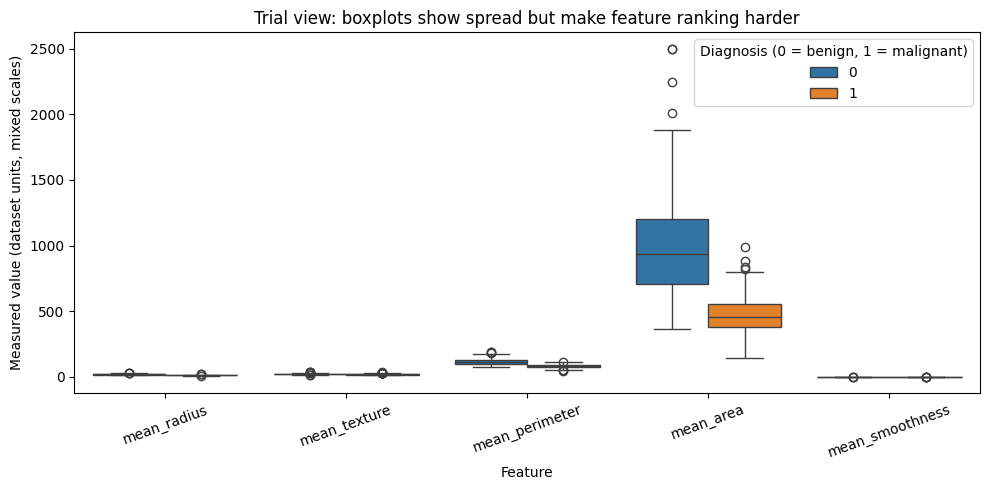

In [74]:
feature_cols = ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness']
trial_df = df.melt(id_vars='diagnosis', value_vars=feature_cols, var_name='feature', value_name='value')

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=trial_df, x='feature', y='value', hue='diagnosis', ax=ax)

ax.set_title('Trial view: boxplots show spread but make feature ranking harder')
ax.set_xlabel('Feature')
ax.set_ylabel('Measured value (dataset units, mixed scales)')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Diagnosis (0 = benign, 1 = malignant)')

plt.tight_layout()
plt.show()

### Diagram choice trial for Question 2: boxplot vs heatmap

In the previous cell, I tested a multi-feature boxplot view for the same question.

The boxplot view is useful for spread and outliers, but it becomes hard to rank feature strength cleanly when many features share one axis and use different value scales.

That is why I move to the heatmap next: it gives one comparable correlation scale and makes ranking stronger vs weaker features easier.

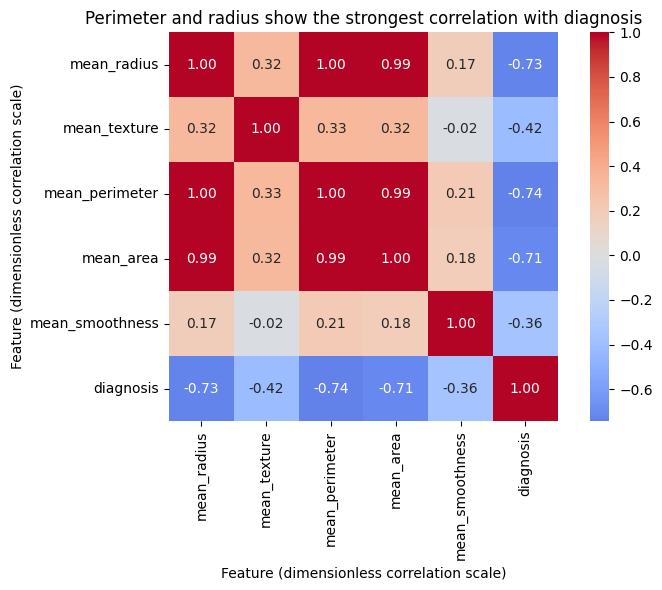

In [75]:
fig, ax = plt.subplots(figsize=(8, 6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax
)

ax.set_title("Perimeter and radius show the strongest correlation with diagnosis")
ax.set_xlabel('Feature (dimensionless correlation scale)')
ax.set_ylabel('Feature (dimensionless correlation scale)')
plt.tight_layout()
plt.show()

### How to read this heatmap

A quick way to read it:

1. The chart is mirrored. Correlation between A and B is the same as between B and A.
2. The diagonal is always 1.0 because each variable perfectly matches itself.
3. Correlations with `diagnosis` are negative here. In this dataset, benign cases (0) tend to have higher measurement values, while malignant cases (1) tend to have lower ones.

So for this project, the strongest feature is the one with the largest absolute correlation value next to `diagnosis`.

### What this tells me (Question 2)

Looking at the `diagnosis` relationships, I get:

| Feature | Correlation with diagnosis |
|---|---|
| mean_perimeter | -0.74 (strongest) |
| mean_radius | -0.73 |
| mean_area | -0.71 |
| mean_texture | -0.42 |
| mean_smoothness | -0.36 (weakest) |

For my second question, the answer is clear: `mean_perimeter` is the strongest single feature, with `mean_radius` and `mean_area` very close behind.

This also explains my next step. Since `mean_perimeter` and `mean_radius` are the top two, I combine them in one scatterplot to test whether they separate the groups better together.

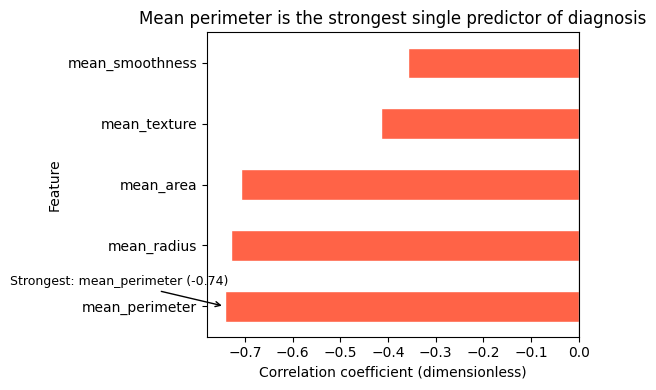

In [76]:
# Pull out just the correlations with diagnosis and drop diagnosis itself
diag_corr = df.corr(numeric_only=True)['diagnosis'].drop('diagnosis').sort_values()

fig, ax = plt.subplots(figsize=(7, 4))

colors = ['tomato' if v < 0 else 'steelblue' for v in diag_corr]
diag_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)
strongest_feature = diag_corr.abs().idxmax()
strongest_value = diag_corr[strongest_feature]
y_pos = diag_corr.index.tolist().index(strongest_feature)
ax.annotate(
    f'Strongest: {strongest_feature} ({strongest_value:.2f})',
    xy=(strongest_value, y_pos),
    xytext=(strongest_value - 0.45, y_pos + 0.35),
    arrowprops=dict(arrowstyle='->', color='black', lw=1),
    fontsize=9
)

ax.set_title('Mean perimeter is the strongest single predictor of diagnosis')
ax.set_xlabel('Correlation coefficient (dimensionless)')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

## Scatterplot: Putting the top two features together

Now I move to question 3: if I combine two strong features, do I get clearer separation?

From the correlation step, `mean_perimeter` and `mean_radius` were strongest, so I plot them against each other.

In this scatterplot, each dot is one patient:
- x-axis: `mean_radius`
- y-axis: `mean_perimeter`
- color: diagnosis (blue = benign, red = malignant)

If the colors cluster in different areas, that means the two-feature combination gives a cleaner signal than one feature alone.

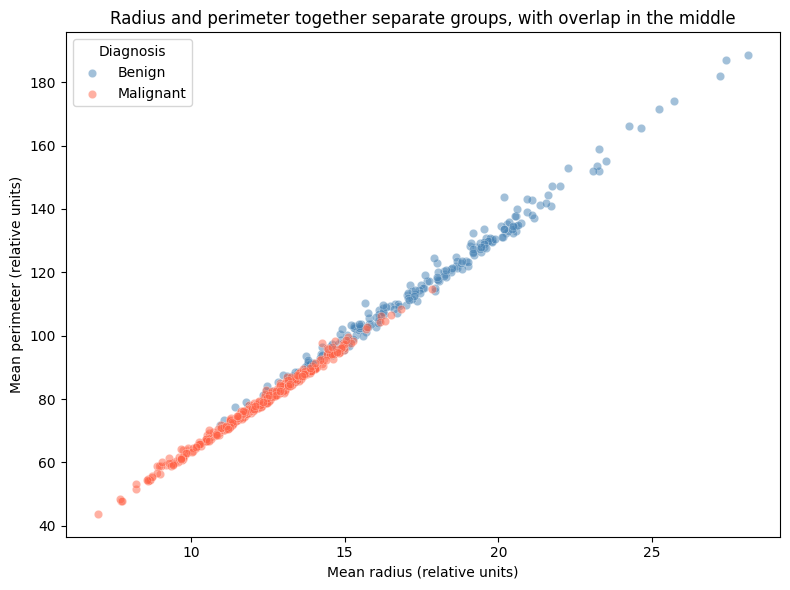

In [77]:
plot_df = df.copy()
plot_df['diagnosis_label'] = plot_df['diagnosis'].map({0: 'Benign', 1: 'Malignant'})

fig, ax = plt.subplots(figsize=(8, 6))

for label, color in [('Benign', 'steelblue'), ('Malignant', 'tomato')]:
    group = plot_df[plot_df['diagnosis_label'] == label]
    ax.scatter(
        group['mean_radius'],
        group['mean_perimeter'],
        label=label,
        color=color,
        alpha=0.5,
        edgecolors='white',
        linewidths=0.3
    )

ax.set_title('Radius and perimeter together separate groups, with overlap in the middle')
ax.set_xlabel('Mean radius (relative units)')
ax.set_ylabel('Mean perimeter (relative units)')
ax.legend(title='Diagnosis')

plt.tight_layout()
plt.show()

### What this tells me (Question 3)

The dots form a clear diagonal from lower-left to upper-right. That makes sense: radius and perimeter are tightly linked, so larger cells score higher on both.

I can also see practical separation:
- red points (malignant) are concentrated more in the lower-left
- blue points (benign) are concentrated more in the upper-right

So the answer to question 3 is yes: using these two features together gives a clearer split, even if there is still overlap in the middle.

This completes the flow of my analysis:
- first I checked group differences,
- then I found the strongest single feature,
- and finally I tested whether two strong features improve separation.

## Summary

One way to read my whole analysis is as a step-by-step narrowing process.

I started by checking whether benign and malignant groups look different at all. They do: benign cases are generally higher in `mean_radius`, `mean_perimeter`, and `mean_area`.

Then I asked which single feature is strongest. Correlation showed that `mean_perimeter` is strongest (about -0.74), with `mean_radius` and `mean_area` very close.

After that, I combined the two strongest features in a scatterplot. That gave clearer visual separation than one feature alone, which helped answer my third question.

What I learned: the same pattern keeps appearing across tables, numeric checks, and plots, which makes the conclusion more trustworthy.

What I still cannot know from this dataset: it represents one hospital population and only a subset of all possible features, so these findings should be treated as strong patterns in this sample, not universal rules.